# UCLA MSBA Hands-On Lab: Time-Series Foundation Models and Evaluation

This notebook is designed to mirror the workflow in your slides:

- **Foundation-model lifecycle**: pretrain once, adapt to many downstream tasks
- **Time-series foundation model usage**: zero-shot, few-shot, and fine-tuned forecasting
- **Evaluation discipline**: temporal splits, rolling-origin testing, and domain metrics (MAE, RMSE, sMAPE, MASE)

## What students will do

1. Generate a multi-domain synthetic corpus (a stand-in for large pretraining data)
2. Pretrain a **global forecasting model** across many series
3. Evaluate on a new target series in **zero-shot** mode
4. Fine-tune with **few-shot** and **full-data** target samples
5. Compare models using **MAE / RMSE / sMAPE / MASE** and rolling-origin backtests

This default notebook path is intentionally **CPU-friendly** and uses only `numpy` and `pandas`.

## Setup Notes

- The core lab runs with `numpy` + `pandas` only.
- Plotting is optional (`matplotlib`).
- For a **real TSFM** (Chronos/TimesFM) with the same evaluation harness, use **`tsfm_chronos_eval_lab.ipynb`**.

In [1]:
import math
import numpy as np
import pandas as pd
from dataclasses import dataclass

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(suppress=True, precision=4)

# Optional plotting (not required for the lab to run)
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception as e:
    HAS_MPL = False
    print(f"matplotlib not available ({type(e).__name__}): plots will be skipped")

## How this lab maps to real TSFMs

This notebook uses a **global, foundation-style forecasting model** (a simple multi-output ridge forecaster) to illustrate the workflow:

- **Pretraining corpus** → many source series across domains
- **Zero-shot transfer** → evaluate on a new unseen target series with no target training
- **Few-shot adaptation** → fine-tune with a small number of target windows
- **Full fine-tune** → use all target training data

The model is intentionally simple for easy learning. The *workflow* is what mirrors real TSFMs (Chronos, TimesFM, TimeGPT, etc.). To use an actual open-source TSFM (Chronos) with this style of evaluation, see **`tsfm_chronos_eval_lab.ipynb`**.

In [2]:
# Global configuration for the exercise
CONTEXT_LEN = 48       # input window length
HORIZON = 12           # forecast horizon
SEASONAL_PERIOD = 24   # hourly-like seasonality for synthetic examples
TRAIN_RATIO = 0.7
VAL_RATIO = 0.1

print({
    'context_len': CONTEXT_LEN,
    'horizon': HORIZON,
    'seasonal_period': SEASONAL_PERIOD,
    'train_ratio': TRAIN_RATIO,
    'val_ratio': VAL_RATIO,
})

{'context_len': 48, 'horizon': 12, 'seasonal_period': 24, 'train_ratio': 0.7, 'val_ratio': 0.1}


## Step 1: Generate a multi-domain synthetic pretraining corpus

We simulate several domains (retail demand, energy load, web traffic, finance-like series), each with different trend/seasonality/noise/regime characteristics.

This gives a realistic intuition for why **global pretraining** can transfer useful patterns.

In [3]:
def make_synthetic_series(length: int, domain: str, rng: np.random.Generator) -> np.ndarray:
    t = np.arange(length)
    base = rng.uniform(20, 120)
    noise_scale = rng.uniform(0.5, 3.0)

    if domain == 'retail':
        trend = rng.uniform(-0.02, 0.08) * t
        daily = rng.uniform(4, 15) * np.sin(2 * np.pi * t / 24 + rng.uniform(0, 2*np.pi))
        weekly = rng.uniform(3, 10) * np.sin(2 * np.pi * t / (24*7) + rng.uniform(0, 2*np.pi))
        promo = (rng.random(length) < 0.03).astype(float) * rng.uniform(8, 30)
        y = base + trend + daily + weekly + promo + rng.normal(0, noise_scale, length)
    elif domain == 'energy':
        trend = rng.uniform(-0.01, 0.03) * t
        daily = rng.uniform(8, 22) * np.sin(2 * np.pi * t / 24 + rng.uniform(0, 2*np.pi))
        temp_effect = rng.uniform(5, 12) * np.cos(2 * np.pi * t / (24*30) + rng.uniform(0, 2*np.pi))
        y = base + trend + daily + temp_effect + rng.normal(0, noise_scale * 1.5, length)
    elif domain == 'web':
        trend = rng.uniform(0.0, 0.1) * t
        daily = rng.uniform(6, 20) * np.sin(2 * np.pi * t / 24 + rng.uniform(0, 2*np.pi))
        bursts = np.zeros(length)
        for _ in range(rng.integers(2, 6)):
            c = rng.integers(0, length)
            w = rng.uniform(3, 20)
            a = rng.uniform(10, 40)
            bursts += a * np.exp(-0.5 * ((t - c) / w) ** 2)
        y = base + trend + daily + bursts + rng.normal(0, noise_scale * 2.0, length)
    elif domain == 'finance':
        # Price-like random walk with weak periodicity and volatility shifts
        shocks = rng.normal(0, noise_scale, length)
        vol = 1 + 0.8 * (np.sin(2 * np.pi * t / 120 + rng.uniform(0, 2*np.pi)) > 0)
        walk = np.cumsum(shocks * vol)
        cyc = rng.uniform(1, 5) * np.sin(2 * np.pi * t / 24 + rng.uniform(0, 2*np.pi))
        y = base + walk + cyc
    else:
        trend = rng.uniform(-0.03, 0.03) * t
        seasonal = rng.uniform(2, 8) * np.sin(2 * np.pi * t / 24 + rng.uniform(0, 2*np.pi))
        y = base + trend + seasonal + rng.normal(0, noise_scale, length)

    # Regime shift (common real-world behavior)
    if rng.random() < 0.6:
        split = rng.integers(length // 3, 2 * length // 3)
        y[split:] += rng.uniform(-15, 20)

    # Keep non-negative for many business use cases
    y = np.maximum(y, 0.1)
    return y.astype(float)


def build_pretraining_corpus(n_series_per_domain=40, length=320, seed=42):
    local_rng = np.random.default_rng(seed)
    # Keep source domains reasonably related to the downstream task so transfer is visible in-class.
    domains = ['retail', 'energy', 'web']
    rows = []
    for domain in domains:
        for i in range(n_series_per_domain):
            rows.append({
                'series_id': f'{domain}_{i:03d}',
                'domain': domain,
                'values': make_synthetic_series(length, domain, local_rng)
            })
    return rows

corpus = build_pretraining_corpus(n_series_per_domain=35, length=320, seed=SEED)
print('num series:', len(corpus))
print('domains:', pd.Series([r['domain'] for r in corpus]).value_counts().to_dict())
print('example series shape:', corpus[0]['values'].shape)

num series: 105
domains: {'retail': 35, 'energy': 35, 'web': 35}
example series shape: (320,)


In [4]:
# Build a target series that looks like a downstream business forecasting problem
# (domain shifted compared to training corpus, with a stronger late regime change)
def build_target_series(length=420, seed=7):
    r = np.random.default_rng(seed)
    t = np.arange(length)

    level = 140 + 0.04 * t
    daily = 18 * np.sin(2 * np.pi * t / 24 + 0.4)
    weekly = 10 * np.sin(2 * np.pi * t / (24 * 7) - 0.8)
    promo = (r.random(length) < 0.025).astype(float) * r.uniform(15, 45, length)
    noise = r.normal(0, 4.0, length)
    y = level + daily + weekly + promo + noise

    # Regime shifts and demand shock to stress evaluation
    y[260:] += 18
    y[330:] += np.linspace(0, 22, length - 330)
    y[350:365] -= 20

    return np.maximum(y, 0.1)

target_series = build_target_series()
print('target length:', len(target_series), 'min/max:', float(target_series.min()), float(target_series.max()))

target length: 420 min/max: 112.37316847822494 225.66191743798876


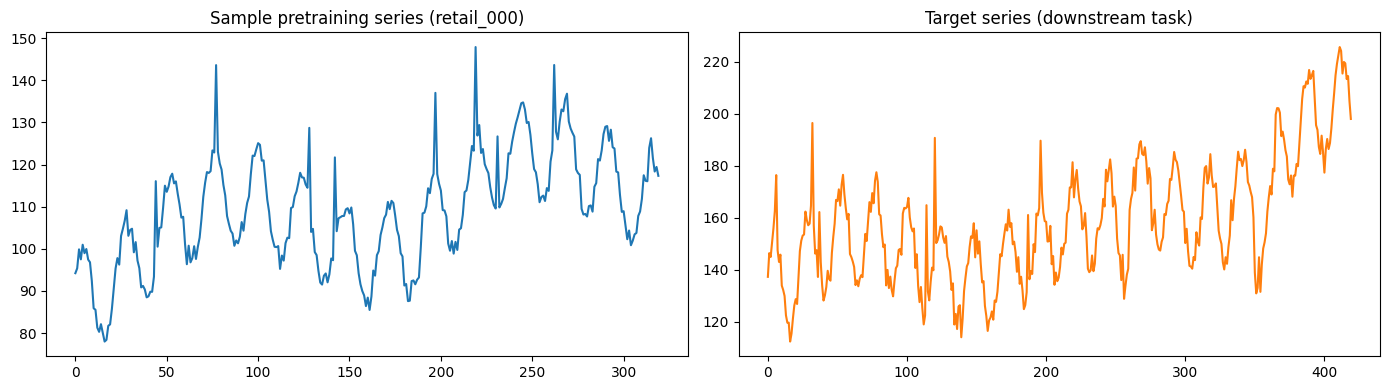

In [5]:
if HAS_MPL:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(corpus[0]['values'])
    ax[0].set_title(f"Sample pretraining series ({corpus[0]['series_id']})")
    ax[1].plot(target_series, color='tab:orange')
    ax[1].set_title('Target series (downstream task)')
    plt.tight_layout()
else:
    print('Plot skipped (matplotlib unavailable).')

## Step 2: Temporal splits (train / validation / test)

We never shuffle time series data. We split chronologically.

In [6]:
@dataclass
class TimeSplit:
    train: np.ndarray
    val: np.ndarray
    test: np.ndarray


def temporal_split(y: np.ndarray, train_ratio=0.7, val_ratio=0.1) -> TimeSplit:
    n = len(y)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val
    assert n_train > 0 and n_val > 0 and n_test > 0
    return TimeSplit(
        train=y[:n_train],
        val=y[n_train:n_train + n_val],
        test=y[n_train + n_val:],
    )

split = temporal_split(target_series, TRAIN_RATIO, VAL_RATIO)
print({k: len(getattr(split, k)) for k in ['train', 'val', 'test']})

{'train': 294, 'val': 42, 'test': 84}


## Step 3: Windowing + features + evaluation metrics

We build supervised training windows from historical contexts and future horizons.

In [7]:
def make_windows(y: np.ndarray, context_len: int, horizon: int, stride: int = 1):
    X_ctx, Y = [], []
    for start in range(0, len(y) - context_len - horizon + 1, stride):
        x = y[start:start + context_len]
        z = y[start + context_len:start + context_len + horizon]
        X_ctx.append(x)
        Y.append(z)
    if not X_ctx:
        return np.empty((0, context_len)), np.empty((0, horizon))
    return np.vstack(X_ctx), np.vstack(Y)


def summarize_context(ctx: np.ndarray, seasonal_period: int = 24) -> tuple[np.ndarray, float, float]:
    mean = float(np.mean(ctx))
    std = float(np.std(ctx) + 1e-6)
    z = (ctx - mean) / std

    # Compact, interpretable feature vector
    feats = []
    feats.extend(z)                                    # full context lags
    feats.extend(np.diff(z[-24:]))                      # short-term changes
    feats.append(float(z[-1]))                          # last value
    feats.append(float(np.mean(z[-6:])))                # recent mean
    feats.append(float(np.mean(z[-24:])))               # context mean (z-space ~0)
    feats.append(float(np.std(z[-24:])))                # local volatility

    # Trend slope via simple least squares on normalized context
    x = np.arange(len(z), dtype=float)
    x_centered = x - x.mean()
    slope = float((x_centered @ z) / ((x_centered @ x_centered) + 1e-6))
    feats.append(slope)

    # Seasonal anchors (if available)
    if len(ctx) >= seasonal_period:
        feats.append(float(z[-seasonal_period]))
    else:
        feats.append(float(z[0]))
    if len(ctx) >= 2 * seasonal_period:
        feats.append(float(z[-2 * seasonal_period]))
    else:
        feats.append(float(z[0]))

    # NOTE: We omit absolute-time phase features here because this demo windowizer does not retain timestamp indices.

    return np.array(feats, dtype=float), mean, std


def featurize_windows(X_ctx: np.ndarray, Y: np.ndarray, seasonal_period: int = 24):
    Xf, Y_norm, stats = [], [], []
    for ctx, y_future in zip(X_ctx, Y):
        f, mean, std = summarize_context(ctx, seasonal_period)
        Xf.append(f)
        Y_norm.append((y_future - mean) / std)
        stats.append((mean, std))
    return np.vstack(Xf), np.vstack(Y_norm), np.array(stats)


def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def smape(y_true, y_pred, eps=1e-6):
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100 * np.mean(2 * np.abs(y_true - y_pred) / denom))


def mase(y_true, y_pred, train_series, m=1, eps=1e-6):
    if len(train_series) <= m:
        return float('nan')
    scale = np.mean(np.abs(train_series[m:] - train_series[:-m])) + eps
    return float(np.mean(np.abs(y_true - y_pred)) / scale)


def metric_table(y_true, y_pred, train_series, seasonal_period=24):
    return {
        'MAE': mae(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred),
        'MASE(m=1)': mase(y_true, y_pred, train_series, m=1),
        f'MASE(m={seasonal_period})': mase(y_true, y_pred, train_series, m=seasonal_period),
    }

## Step 4: Baselines (Naive and Seasonal Naive)

These baselines are critical. In real forecasting, a complex model that fails to beat a seasonal naive baseline is usually not production-ready.

In [8]:
def predict_last_value(contexts: np.ndarray, horizon: int) -> np.ndarray:
    return np.repeat(contexts[:, [-1]], horizon, axis=1)


def predict_seasonal_naive(contexts: np.ndarray, horizon: int, seasonal_period: int = 24) -> np.ndarray:
    preds = []
    for ctx in contexts:
        out = []
        for h in range(horizon):
            idx = len(ctx) - seasonal_period + (h % seasonal_period)
            if idx < 0 or idx >= len(ctx):
                out.append(ctx[-1])
            else:
                out.append(ctx[idx])
        preds.append(out)
    return np.array(preds, dtype=float)

## Step 5: A simple foundation-style global forecaster (multi-output ridge)

This model is intentionally simple and fast, but the **workflow** is the important part:

- Train once on many source-series windows (global pretraining)
- Reuse weights on a new target (zero-shot)
- Adapt with few target windows (fine-tuning)

In [9]:
class GlobalRidgeForecaster:
    def __init__(self, ridge=1.0, pred_clip=4.0):
        self.ridge = float(ridge)
        self.pred_clip = float(pred_clip)
        self.W = None  # shape: (n_features + 1, horizon)
        self.feature_dim = None
        self.x_mean = None
        self.x_std = None

    def _fit_feature_scaler(self, X: np.ndarray):
        self.x_mean = X.mean(axis=0)
        self.x_std = X.std(axis=0) + 1e-6
        # Constant-ish features can blow up numerically after standardization.
        self.x_std[self.x_std < 1e-3] = 1.0

    def _transform_X(self, X: np.ndarray) -> np.ndarray:
        return (X - self.x_mean) / self.x_std

    def _augment(self, X: np.ndarray) -> np.ndarray:
        return np.hstack([X, np.ones((len(X), 1))])

    def fit(self, X: np.ndarray, Y: np.ndarray, prior_W: np.ndarray | None = None, prior_strength: float = 0.0):
        self._fit_feature_scaler(X)
        Xs = self._transform_X(X)
        XA = self._augment(Xs)
        n_features = XA.shape[1]
        I = np.eye(n_features)
        I[-1, -1] = 0.0  # do not regularize bias term heavily
        A = XA.T @ XA + self.ridge * I
        B = XA.T @ Y

        if prior_W is not None and prior_strength > 0:
            # MAP-style adaptation around pretrained weights: ||W-W0||^2 penalty
            A = A + prior_strength * I
            B = B + prior_strength * prior_W

        self.W = np.linalg.solve(A, B)
        self.feature_dim = X.shape[1]
        return self

    def predict_normalized(self, X: np.ndarray) -> np.ndarray:
        Xs = self._transform_X(X)
        XA = self._augment(Xs)
        Y_norm = XA @ self.W
        return np.clip(Y_norm, -self.pred_clip, self.pred_clip)

    def predict(self, X: np.ndarray, stats: np.ndarray) -> np.ndarray:
        Y_norm = self.predict_normalized(X)
        means = stats[:, [0]]
        stds = stats[:, [1]]
        return Y_norm * stds + means



## Step 6: Pretrain the global model on source domains

In [10]:
def sample_pretraining_windows(corpus_rows, context_len, horizon, max_windows_per_series=30, stride=4, seed=42):
    r = np.random.default_rng(seed)
    Xf_list, Y_list = [], []

    for row in corpus_rows:
        X_ctx, Y = make_windows(row['values'], context_len, horizon, stride=stride)
        if len(X_ctx) == 0:
            continue
        Xf, Y_norm, _ = featurize_windows(X_ctx, Y, seasonal_period=SEASONAL_PERIOD)

        if len(Xf) > max_windows_per_series:
            idx = r.choice(len(Xf), size=max_windows_per_series, replace=False)
            Xf = Xf[idx]
            Y_norm = Y_norm[idx]

        Xf_list.append(Xf)
        Y_list.append(Y_norm)

    X_pre = np.vstack(Xf_list)
    Y_pre = np.vstack(Y_list)
    return X_pre, Y_pre

X_pre, Y_pre = sample_pretraining_windows(corpus, CONTEXT_LEN, HORIZON, max_windows_per_series=36, stride=3, seed=SEED)
print('pretraining feature matrix:', X_pre.shape)
print('pretraining targets:', Y_pre.shape)

pretrained_model = GlobalRidgeForecaster(ridge=2.0).fit(X_pre, Y_pre)
print('pretrained W shape:', pretrained_model.W.shape)

pretraining feature matrix: (3780, 78)
pretraining targets: (3780, 12)
pretrained W shape: (79, 12)


## Step 7: Build target evaluation windows (chronological)

We use rolling-origin windows across the test region. Each forecast uses only the past context available at that point.

In [11]:
def rolling_origin_windows(full_series: np.ndarray, train_end: int, val_end: int, context_len: int, horizon: int, stride: int = None):
    if stride is None:
        stride = horizon
    starts = []
    X_ctx, Y = [], []
    test_start = val_end
    last_start = len(full_series) - context_len - horizon
    for start in range(test_start - context_len, last_start + 1, stride):
        if start < 0:
            continue
        ctx_end = start + context_len
        fut_end = ctx_end + horizon
        if fut_end > len(full_series):
            break
        # Ensure forecast origin is in or after test period
        if ctx_end < test_start:
            continue
        starts.append(start)
        X_ctx.append(full_series[start:ctx_end])
        Y.append(full_series[ctx_end:fut_end])
    return np.array(starts), np.vstack(X_ctx), np.vstack(Y)

n = len(target_series)
n_train = len(split.train)
n_val = len(split.val)
train_end = n_train
val_end = n_train + n_val
starts_test, X_ctx_test, Y_test = rolling_origin_windows(target_series, train_end, val_end, CONTEXT_LEN, HORIZON, stride=HORIZON)
Xf_test, Y_test_norm, stats_test = featurize_windows(X_ctx_test, Y_test, seasonal_period=SEASONAL_PERIOD)
print('test rolling windows:', X_ctx_test.shape, Y_test.shape)

test rolling windows: (7, 48) (7, 12)


## Step 8: Evaluate baselines and zero-shot transfer

In [12]:
def flatten_forecasts(y):
    return y.reshape(-1)

results = []

# Baseline: last value
pred_last = predict_last_value(X_ctx_test, HORIZON)
results.append({'model': 'NaiveLast', **metric_table(flatten_forecasts(Y_test), flatten_forecasts(pred_last), split.train, SEASONAL_PERIOD)})

# Baseline: seasonal naive
pred_seasonal = predict_seasonal_naive(X_ctx_test, HORIZON, SEASONAL_PERIOD)
results.append({'model': f'SeasonalNaive(m={SEASONAL_PERIOD})', **metric_table(flatten_forecasts(Y_test), flatten_forecasts(pred_seasonal), split.train, SEASONAL_PERIOD)})

# Zero-shot (pretrained global model, no target fitting)
pred_zero = pretrained_model.predict(Xf_test, stats_test)
results.append({'model': 'GlobalPretrained_ZeroShot', **metric_table(flatten_forecasts(Y_test), flatten_forecasts(pred_zero), split.train, SEASONAL_PERIOD)})

pd.DataFrame(results).sort_values('sMAPE')

,model,MAE,RMSE,sMAPE,MASE(m=1),MASE(m=24)
2,GlobalPretrained_ZeroShot,9.003533,11.529310,5.014857,1.391663,1.019606
0,NaiveLast,14.409696,17.528756,8.051937,2.227286,1.631827
1,SeasonalNaive(m=24),14.471648,18.535543,8.204276,2.236861,1.638843


## Step 9: Fine-tune on target data (few-shot and full)

This is the key “foundation model in practice” step:

- **Few-shot**: use a small number of target windows, regularized toward pretrained weights
- **Full fine-tune**: use all target train windows, still starting from the pretrained prior

In [13]:
# Create training windows from target TRAIN split only (strictly before validation/test)
X_ctx_train, Y_train = make_windows(split.train, CONTEXT_LEN, HORIZON, stride=1)
Xf_train, Y_train_norm, stats_train = featurize_windows(X_ctx_train, Y_train, seasonal_period=SEASONAL_PERIOD)
print('target-train windows:', Xf_train.shape, Y_train_norm.shape)

# Few-shot subset (small sample of target windows)
few_shot_n = min(32, len(Xf_train))
few_idx = np.linspace(0, len(Xf_train)-1, few_shot_n, dtype=int)
Xf_few = Xf_train[few_idx]
Y_few = Y_train_norm[few_idx]
print('few-shot windows:', Xf_few.shape)

target-train windows: (235, 78) (235, 12)
few-shot windows: (32, 78)


In [14]:
# Fine-tune with a prior around pretrained weights (MAP adaptation)
W0 = pretrained_model.W.copy()

few_shot_model = GlobalRidgeForecaster(ridge=1.0).fit(
    Xf_few,
    Y_few,
    prior_W=W0,
    prior_strength=25.0,
)
pred_few = few_shot_model.predict(Xf_test, stats_test)

full_ft_model = GlobalRidgeForecaster(ridge=1.0).fit(
    Xf_train,
    Y_train_norm,
    prior_W=W0,
    prior_strength=8.0,
)
pred_full_ft = full_ft_model.predict(Xf_test, stats_test)

# Target-only model trained from scratch (for comparison)
target_only_model = GlobalRidgeForecaster(ridge=1.0).fit(Xf_train, Y_train_norm)
pred_target_only = target_only_model.predict(Xf_test, stats_test)

results_ft = [
    {'model': 'GlobalPretrained_ZeroShot', **metric_table(flatten_forecasts(Y_test), flatten_forecasts(pred_zero), split.train, SEASONAL_PERIOD)},
    {'model': 'GlobalPretrained_FewShotFT', **metric_table(flatten_forecasts(Y_test), flatten_forecasts(pred_few), split.train, SEASONAL_PERIOD)},
    {'model': 'GlobalPretrained_FullFT', **metric_table(flatten_forecasts(Y_test), flatten_forecasts(pred_full_ft), split.train, SEASONAL_PERIOD)},
    {'model': 'TargetOnly_FromScratch', **metric_table(flatten_forecasts(Y_test), flatten_forecasts(pred_target_only), split.train, SEASONAL_PERIOD)},
]

pd.DataFrame(results_ft).sort_values('sMAPE')

,model,MAE,RMSE,sMAPE,MASE(m=1),MASE(m=24)
0,GlobalPretrained_ZeroShot,9.003533,11.529310,5.014857,1.391663,1.019606
1,GlobalPretrained_FewShotFT,9.035657,11.842351,5.020895,1.396628,1.023243
2,GlobalPretrained_FullFT,9.569736,11.923414,5.337524,1.479180,1.083725
3,TargetOnly_FromScratch,9.677925,12.057931,5.400927,1.495903,1.095977


In [15]:
# Combine all results into one comparison table
all_results = pd.concat([
    pd.DataFrame(results),
    pd.DataFrame(results_ft).query("model not in ['GlobalPretrained_ZeroShot']")
], ignore_index=True)
all_results.sort_values('sMAPE').reset_index(drop=True)

,model,MAE,RMSE,sMAPE,MASE(m=1),MASE(m=24)
0,GlobalPretrained_ZeroShot,9.003533,11.529310,5.014857,1.391663,1.019606
1,GlobalPretrained_FewShotFT,9.035657,11.842351,5.020895,1.396628,1.023243
2,GlobalPretrained_FullFT,9.569736,11.923414,5.337524,1.479180,1.083725
3,TargetOnly_FromScratch,9.677925,12.057931,5.400927,1.495903,1.095977
4,NaiveLast,14.409696,17.528756,8.051937,2.227286,1.631827
5,SeasonalNaive(m=24),14.471648,18.535543,8.204276,2.236861,1.638843


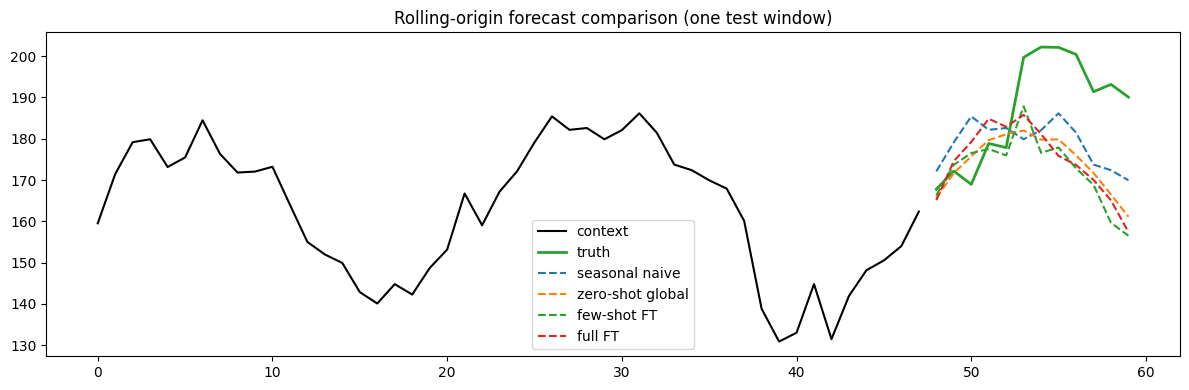

In [16]:
if HAS_MPL:
    # Visualize one rolling-origin forecast example
    i = min(2, len(X_ctx_test)-1)
    ctx = X_ctx_test[i]
    truth = Y_test[i]

    fig, ax = plt.subplots(figsize=(12, 4))
    x_ctx = np.arange(len(ctx))
    x_fut = np.arange(len(ctx), len(ctx)+HORIZON)
    ax.plot(x_ctx, ctx, label='context', color='black')
    ax.plot(x_fut, truth, label='truth', color='tab:green', linewidth=2)
    ax.plot(x_fut, pred_seasonal[i], label='seasonal naive', linestyle='--')
    ax.plot(x_fut, pred_zero[i], label='zero-shot global', linestyle='--')
    ax.plot(x_fut, pred_few[i], label='few-shot FT', linestyle='--')
    ax.plot(x_fut, pred_full_ft[i], label='full FT', linestyle='--')
    ax.set_title('Rolling-origin forecast comparison (one test window)')
    ax.legend(loc='best')
    plt.tight_layout()
else:
    print('Plot skipped (matplotlib unavailable).')

## Step 10: Robustness check with rolling-origin metrics over time

Instead of only one aggregate score, inspect **how metrics drift across forecast origins**.

In [17]:
def per_window_metrics(Y_true: np.ndarray, Y_pred: np.ndarray) -> pd.DataFrame:
    rows = []
    for i in range(len(Y_true)):
        rows.append({
            'window': i,
            'MAE': mae(Y_true[i], Y_pred[i]),
            'RMSE': rmse(Y_true[i], Y_pred[i]),
            'sMAPE': smape(Y_true[i], Y_pred[i]),
        })
    return pd.DataFrame(rows)

pw = {
    'SeasonalNaive': per_window_metrics(Y_test, pred_seasonal),
    'ZeroShot': per_window_metrics(Y_test, pred_zero),
    'FewShotFT': per_window_metrics(Y_test, pred_few),
    'FullFT': per_window_metrics(Y_test, pred_full_ft),
}

summary_pw = pd.DataFrame({k: v[['MAE','RMSE','sMAPE']].mean().add_prefix('avg_') for k, v in pw.items()}).T
summary_pw

,avg_MAE,avg_RMSE,avg_sMAPE
SeasonalNaive,14.471648,16.011127,8.204276
ZeroShot,9.003533,10.446289,5.014857
FewShotFT,9.035657,10.824080,5.020895
FullFT,9.569736,10.772417,5.337524


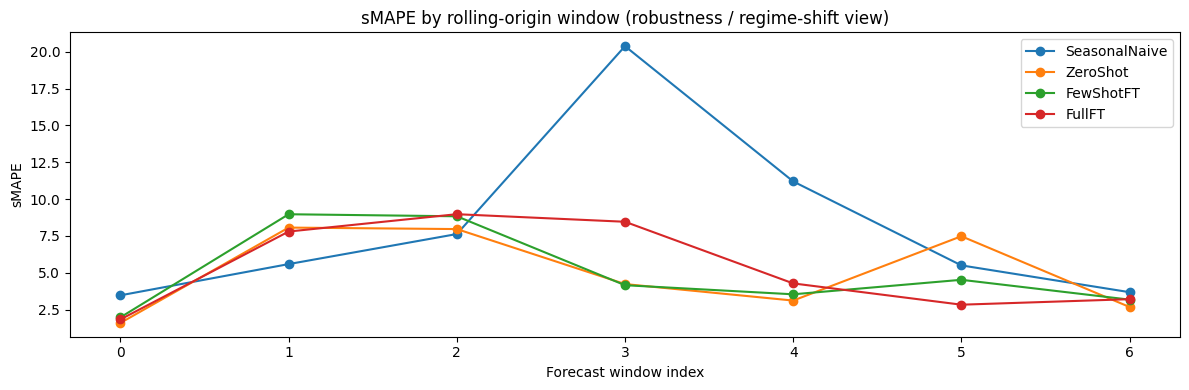

In [18]:
if HAS_MPL:
    fig, ax = plt.subplots(figsize=(12, 4))
    for name, dfm in pw.items():
        ax.plot(dfm['window'], dfm['sMAPE'], marker='o', label=name)
    ax.set_title('sMAPE by rolling-origin window (robustness / regime-shift view)')
    ax.set_xlabel('Forecast window index')
    ax.set_ylabel('sMAPE')
    ax.legend(loc='best')
    plt.tight_layout()
else:
    print('Plot skipped (matplotlib unavailable).')

## Step 11: Student tasks (interactive exercise prompts)

### Core tasks 

1. Change `few_shot_n` to `{8, 16, 32, 64}` and compare the performance curve.
2. Change `SEASONAL_PERIOD` (e.g., 12, 24, 48) and observe baseline sensitivity.
3. Increase the regime shift in `build_target_series()` and inspect which model degrades first.
4. Add a new domain to pretraining corpus (e.g., sensor/IoT) and test transfer impact.
5. Compare **target-only from scratch** vs **pretrained + few-shot** when target train data is very small.

### Discussion questions 

- When does zero-shot transfer help vs hurt?
- Why do we still need strong baselines?
- Which metric best reflects your business objective?
- What failure modes are visible only in rolling-origin plots (not aggregate scores)?